# 전처리 → 자체 GT (SENSE) @ 320×320, 그리고 SENSE vs RSS 비교

readout/phase 모두 **image 도메인에서 320으로 crop**해 **모든 이미지를 320×320 고정**으로 만든다
(획득 phase 폭이 320~580으로 제각각이라, 일관성을 위해 고정 crop 필수).
그 뒤 ESPIRiT 감도맵으로 **SENSE 결합 = GT**를 만들고, **RSS와 같은 이미지인지** 비교한다.

순서: ① readout(kx) 640→320 (image) → ② phase(ky) →320 (image) → ③ ESPIRiT→SENSE GT → ④ SENSE vs RSS

In [1]:
import os, sys, glob
sys.path.insert(0, '/home/sonwonjun/research/MRRecon/code')
import numpy as np, h5py
import matplotlib.pyplot as plt
from MakeDataset import espirit_sens_maps                       # sets up BART
from mrrecon.data.transforms import sense_combine_np, rss_np, center_crop_2d
from mrrecon.metrics import all_metrics, match_scale

RAW='/mnt/d/research/MRRecon/multicoil_val'
f=sorted(glob.glob(RAW+'/*.h5'))[0]
with h5py.File(f,'r') as h:
    s=h['kspace'].shape[0]//2
    kraw=h['kspace'][s]                                         # (15,640,W) raw
    rss_official=h['reconstruction_rss'][s]                     # (320,320) official GT
print('raw k-space',kraw.shape,'| official RSS',rss_official.shape)

klog   = lambda x: np.log(np.abs(x)+1e-9)                       # unified k-space display
ifft1_ro=lambda x: np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(x,axes=-2),axis=-2,norm='ortho'),axes=-2)
fft1_ro =lambda x: np.fft.fftshift(np.fft.fft (np.fft.ifftshift(x,axes=-2),axis=-2,norm='ortho'),axes=-2)
ifft1_pe=lambda x: np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(x,axes=-1),axis=-1,norm='ortho'),axes=-1)
fft1_pe =lambda x: np.fft.fftshift(np.fft.fft (np.fft.ifftshift(x,axes=-1),axis=-1,norm='ortho'),axes=-1)

raw k-space (15, 640, 368) | official RSS (320, 320)


## ① readout(kx) 640→320 (image 도메인) — 1D 변환 단계별
readout만 1D IFFT(→영상) → 영상에서 중앙 320 crop → 1D FFT(→k-space). 아래 행은 중앙 ky=0 라인의 1D 프로파일.

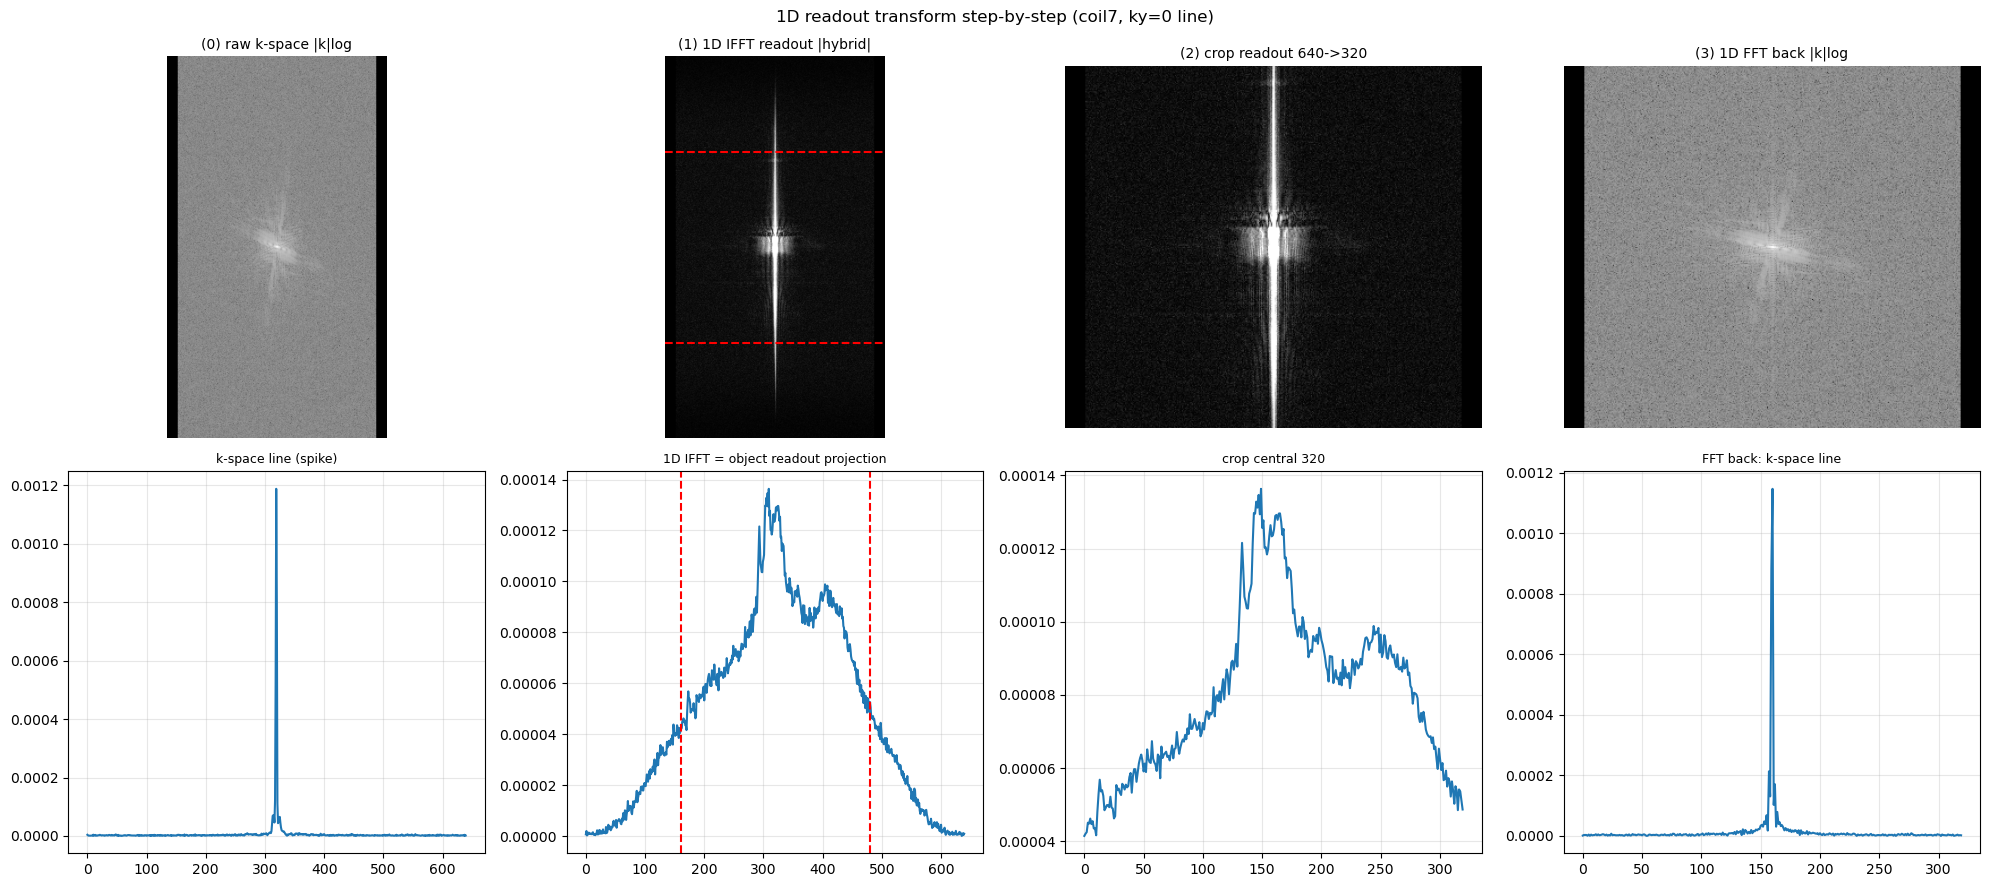

In [2]:
top=(640-320)//2
h1=ifft1_ro(kraw); k1=fft1_ro(h1[:,top:top+320,:])             # (15,320,W)
coil=7; cpe=kraw.shape[2]//2
fig,ax=plt.subplots(2,4,figsize=(20,9))
T=['(0) raw k-space |k|log','(1) 1D IFFT readout |hybrid|','(2) crop readout 640->320','(3) 1D FFT back |k|log']
D=[klog(kraw[coil]),np.abs(h1[coil]),np.abs(h1[coil,top:top+320,:]),klog(k1[coil])]
for j,(d,t) in enumerate(zip(D,T)):
    ax[0,j].imshow(d,cmap='gray',aspect='equal',vmax=None if 'log' in t else 0.3*d.max()); ax[0,j].set_title(t,fontsize=10); ax[0,j].axis('off')
ax[0,1].axhline(top,color='r',ls='--'); ax[0,1].axhline(top+320,color='r',ls='--')
P=[np.abs(kraw[coil,:,cpe]),np.abs(h1[coil,:,cpe]),np.abs(h1[coil,top:top+320,cpe]),np.abs(k1[coil,:,cpe])]
N=['k-space line (spike)','1D IFFT = object readout projection','crop central 320','FFT back: k-space line']
for j,(p,n) in enumerate(zip(P,N)):
    ax[1,j].plot(p); ax[1,j].set_title(n,fontsize=9); ax[1,j].grid(alpha=0.3)
ax[1,1].axvline(top,color='r',ls='--'); ax[1,1].axvline(top+320,color='r',ls='--')
plt.suptitle('1D readout transform step-by-step (coil7, ky=0 line)'); plt.tight_layout(); plt.show()

## ② phase(ky) → 320 (image 도메인, 고정 crop)
획득 폭이 볼륨마다 달라(320~580) **고정 320으로 image center-crop** → 모든 이미지 320×320 일관.
phase도 1D IFFT(→영상) → 중앙 320 crop → 1D FFT.

final k-space (15, 320, 320) (모든 이미지 동일 320x320)


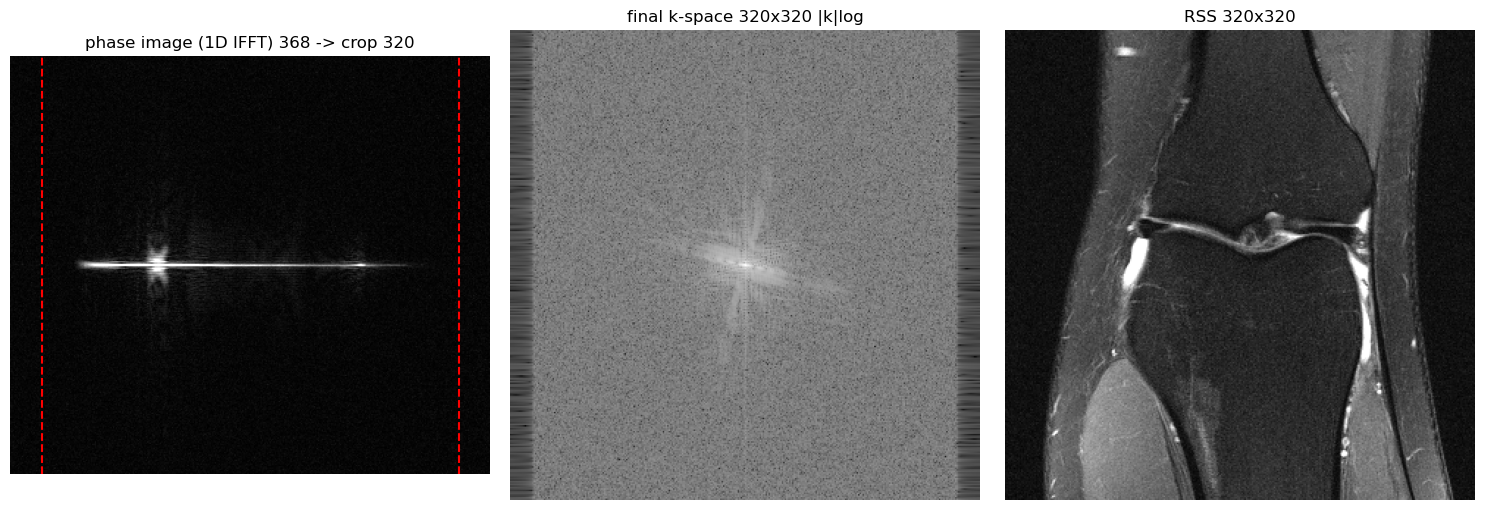

In [3]:
W=k1.shape[-1]; left=(W-320)//2
hp=ifft1_pe(k1); k2=fft1_pe(hp[...,left:left+320])             # (15,320,320)  FINAL k-space
print('final k-space',k2.shape,'(모든 이미지 동일 320x320)')
fig,ax=plt.subplots(1,3,figsize=(15,5))
ax[0].imshow(np.abs(hp[coil]),cmap='gray',aspect='equal',vmax=0.3*np.abs(hp[coil]).max())
ax[0].axvline(left,color='r',ls='--'); ax[0].axvline(left+320,color='r',ls='--'); ax[0].set_title(f'phase image (1D IFFT) {W} -> crop 320'); ax[0].axis('off')
ax[1].imshow(klog(k2[coil]),cmap='gray',aspect='equal'); ax[1].set_title('final k-space 320x320 |k|log'); ax[1].axis('off')
ax[2].imshow(rss_np(k2),cmap='gray',vmax=0.6*rss_np(k2).max()); ax[2].set_title('RSS 320x320'); ax[2].axis('off')
plt.tight_layout(); plt.show()

## ③ ESPIRiT 감도맵 → SENSE GT (320×320)
감도맵은 **full readout(640)** 에서 추정 후 320×320 crop (FOV-가장자리 artifact 방지).

Done.
sens (15, 320, 320) | SENSE GT (320, 320)


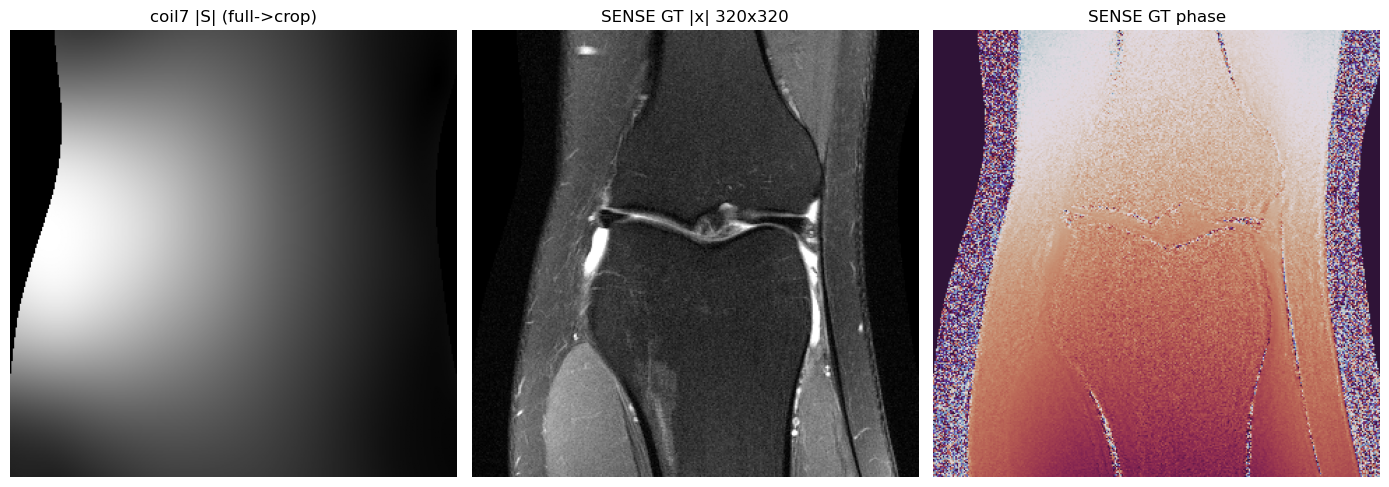

In [4]:
kraw_pc=kraw[:,:,left if False else (kraw.shape[2]-W)//2:]      # (no-op safety)
# sens: full readout, phase 획득영역에서 추정 -> 320x320 crop
sens_full=espirit_sens_maps(kraw)                              # (15,640,W) on full
sens=center_crop_2d(sens_full,320)                            # (15,320,320)
gt_sense=sense_combine_np(k2,sens)                            # (320,320) complex GT
print('sens',sens.shape,'| SENSE GT',gt_sense.shape)
fig,ax=plt.subplots(1,3,figsize=(14,5))
ax[0].imshow(np.abs(sens[coil]),cmap='gray'); ax[0].set_title('coil7 |S| (full->crop)'); ax[0].axis('off')
ax[1].imshow(np.abs(gt_sense),cmap='gray',vmax=0.6*np.abs(gt_sense).max()); ax[1].set_title('SENSE GT |x| 320x320'); ax[1].axis('off')
ax[2].imshow(np.angle(gt_sense),cmap='twilight'); ax[2].set_title('SENSE GT phase'); ax[2].axis('off')
plt.tight_layout(); plt.show()

## ④ SENSE combination vs RSS — 같은 이미지인가?
SENSE(`Σ conj(S)·I`)와 RSS(`sqrt(Σ|I|²)`)를 비교. 구조는 비슷하지만 **결합 방식이 달라 동일하지 않다**
(SENSE는 위상 보존 + 감도맵 가중, RSS는 magnitude). 차이 맵과 SSIM으로 확인.

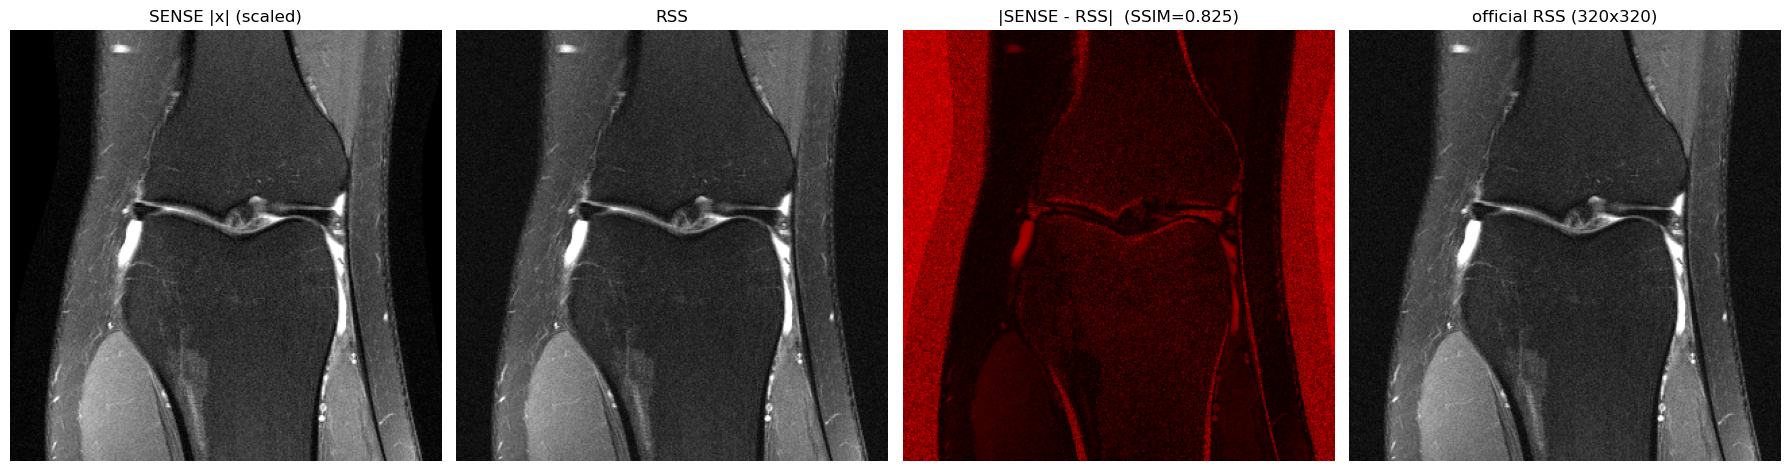

SENSE vs RSS        SSIM = 0.8251   <- 1.0이면 동일, 낮으면 다른 이미지
RSS   vs official   SSIM = 1.0000  (우리 RSS가 공식과 일치하는지)
SENSE vs official   SSIM = 0.8251  (SENSE-vs-RSS 천장)


In [5]:
sense_mag=np.abs(gt_sense); rss=rss_np(k2)
# scale-match for fair magnitude comparison
sm=match_scale(rss, sense_mag)
ssim_sr  = all_metrics(rss, sm)['ssim']
ssim_rgt = all_metrics(rss_official, match_scale(rss_official, rss))['ssim']
ssim_sgt = all_metrics(rss_official, match_scale(rss_official, sense_mag))['ssim']
diff=np.abs(sm-rss)
fig,ax=plt.subplots(1,4,figsize=(18,5))
ax[0].imshow(sm,cmap='gray',vmax=0.6*rss.max()); ax[0].set_title('SENSE |x| (scaled)'); ax[0].axis('off')
ax[1].imshow(rss,cmap='gray',vmax=0.6*rss.max()); ax[1].set_title('RSS'); ax[1].axis('off')
ax[2].imshow(diff,cmap='hot',vmax=0.3*rss.max()); ax[2].set_title(f'|SENSE - RSS|  (SSIM={ssim_sr:.3f})'); ax[2].axis('off')
ax[3].imshow(rss_official,cmap='gray',vmax=0.6*rss_official.max()); ax[3].set_title('official RSS (320x320)'); ax[3].axis('off')
plt.tight_layout(); plt.show()
print(f'SENSE vs RSS        SSIM = {ssim_sr:.4f}   <- 1.0이면 동일, 낮으면 다른 이미지')
print(f'RSS   vs official   SSIM = {ssim_rgt:.4f}  (우리 RSS가 공식과 일치하는지)')
print(f'SENSE vs official   SSIM = {ssim_sgt:.4f}  (SENSE-vs-RSS 천장)')

**결론**
- 모든 이미지를 **320×320으로 고정** (readout/phase 둘 다 image-domain crop) → 일관성 확보
- **SENSE ≠ RSS**: 구조는 비슷해도 결합 방식(SENSE=위상보존·감도맵 가중 / RSS=magnitude)이 달라 SSIM<1
- 우리 RSS는 공식 RSS와 일치(SSIM≈1) → 전처리 정확. SENSE는 별개 도메인(자체 GT)